In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\user\Desktop\Data bricks\ML\collection-recovery-project\Dataset\Dataset-generation.csv")

In [3]:
df.head()

,account_id,dpd,outstanding_balance,customer_income,previous_payments,collection_attempts,region,employment_type,recovered_flag
0,1,132,31871,79234,7,2,South,Business,0
1,2,122,245371,45851,5,1,East,Salaried,0
2,3,44,228524,51279,9,4,North,Self-employed,1
3,4,136,225342,137431,8,5,South,Self-employed,0
4,5,101,184685,116063,6,3,West,Business,0


In [4]:
df.shape

(2000, 9)

Feature Engineering

Payment ratio

In [5]:
df["payment_ratio"] = df["previous_payments"] / df["outstanding_balance"]

In [6]:
df["payment_ratio"].head()

0    0.000220
1    0.000020
2    0.000039
3    0.000036
4    0.000032
Name: payment_ratio, dtype: float64

Debt to income ratio

In [7]:
df["debt_to_income"] = df["outstanding_balance"] / df["customer_income"]

In [8]:
df["debt_to_income"].head()

0    0.402239
1    5.351486
2    4.456483
3    1.639674
4    1.591248
Name: debt_to_income, dtype: float64

Collection intensity

In [9]:
df["attempt_intensity"] = df["collection_attempts"] / (df["dpd"]+1)

In [10]:
df["attempt_intensity"].head()

0    0.015038
1    0.008130
2    0.088889
3    0.036496
4    0.029412
Name: attempt_intensity, dtype: float64

Dpd buckets

In [11]:
df["dpd_bucket"] = pd.cut(
    df["dpd"],
    bins = [0,30,60,90,999],
    labels=["early","soft","hard","late"]
)

In [12]:
df[["dpd_bucket","dpd"]].head()

,dpd_bucket,dpd
0,late,132
1,late,122
2,soft,44
3,late,136
4,late,101


High Risk Behaviour Flag

In [13]:
df["high_risk_flag"] = (
    (df["dpd"] > 60) &
    (df["payment_ratio"] < 0.05)
).astype(int)

In [14]:
df["high_risk_flag"].head()

0    1
1    1
2    0
3    1
4    1
Name: high_risk_flag, dtype: int32

Income segment

In [15]:
df["income_segment"] = pd.cut(
    df["customer_income"],
    bins=[0,30000,70000,150000,1000000],
    labels=["low","mid","upper_mid","high"]
)

In [16]:
df[["income_segment","customer_income"]].head()

,income_segment,customer_income
0,upper_mid,79234
1,mid,45851
2,mid,51279
3,upper_mid,137431
4,upper_mid,116063


In [17]:
df.head()

,account_id,dpd,outstanding_balance,customer_income,previous_payments,collection_attempts,region,employment_type,recovered_flag,payment_ratio,debt_to_income,attempt_intensity,dpd_bucket,high_risk_flag,income_segment
0,1,132,31871,79234,7,2,South,Business,0,0.000220,0.402239,0.015038,late,1,upper_mid
1,2,122,245371,45851,5,1,East,Salaried,0,0.000020,5.351486,0.008130,late,1,mid
2,3,44,228524,51279,9,4,North,Self-employed,1,0.000039,4.456483,0.088889,soft,0,mid
3,4,136,225342,137431,8,5,South,Self-employed,0,0.000036,1.639674,0.036496,late,1,upper_mid
4,5,101,184685,116063,6,3,West,Business,0,0.000032,1.591248,0.029412,late,1,upper_mid


In [18]:
df.isnull().sum()

account_id             0
dpd                    0
outstanding_balance    0
customer_income        0
previous_payments      0
collection_attempts    0
region                 0
employment_type        0
recovered_flag         0
payment_ratio          0
debt_to_income         0
attempt_intensity      0
dpd_bucket             0
high_risk_flag         0
income_segment         0
dtype: int64

In [19]:
df["recovered_flag"].value_counts()

recovered_flag
0    1504
1     496
Name: count, dtype: int64

In [20]:
df.head()

,account_id,dpd,outstanding_balance,customer_income,previous_payments,collection_attempts,region,employment_type,recovered_flag,payment_ratio,debt_to_income,attempt_intensity,dpd_bucket,high_risk_flag,income_segment
0,1,132,31871,79234,7,2,South,Business,0,0.000220,0.402239,0.015038,late,1,upper_mid
1,2,122,245371,45851,5,1,East,Salaried,0,0.000020,5.351486,0.008130,late,1,mid
2,3,44,228524,51279,9,4,North,Self-employed,1,0.000039,4.456483,0.088889,soft,0,mid
3,4,136,225342,137431,8,5,South,Self-employed,0,0.000036,1.639674,0.036496,late,1,upper_mid
4,5,101,184685,116063,6,3,West,Business,0,0.000032,1.591248,0.029412,late,1,upper_mid


Handling categorical columns

In [21]:
cat_columns = df.select_dtypes(include=["object","category"]).columns

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   account_id           2000 non-null   int64   
 1   dpd                  2000 non-null   int64   
 2   outstanding_balance  2000 non-null   int64   
 3   customer_income      2000 non-null   int64   
 4   previous_payments    2000 non-null   int64   
 5   collection_attempts  2000 non-null   int64   
 6   region               2000 non-null   object  
 7   employment_type      2000 non-null   object  
 8   recovered_flag       2000 non-null   int64   
 9   payment_ratio        2000 non-null   float64 
 10  debt_to_income       2000 non-null   float64 
 11  attempt_intensity    2000 non-null   float64 
 12  dpd_bucket           2000 non-null   category
 13  high_risk_flag       2000 non-null   int32   
 14  income_segment       2000 non-null   category
dtypes: category(2), float

In [23]:
df_model = pd.get_dummies(
    df,
    columns=cat_columns,
    drop_first=True
)

In [24]:
df_model

,account_id,dpd,outstanding_balance,customer_income,previous_payments,collection_attempts,recovered_flag,payment_ratio,debt_to_income,attempt_intensity,...,region_South,region_West,employment_type_Salaried,employment_type_Self-employed,dpd_bucket_soft,dpd_bucket_hard,dpd_bucket_late,income_segment_mid,income_segment_upper_mid,income_segment_high
0,1,132,31871,79234,7,2,0,0.000220,0.402239,0.015038,...,True,False,False,False,False,False,True,False,True,False
1,2,122,245371,45851,5,1,0,0.000020,5.351486,0.008130,...,False,False,True,False,False,False,True,True,False,False
2,3,44,228524,51279,9,4,1,0.000039,4.456483,0.088889,...,False,False,False,True,True,False,False,True,False,False
3,4,136,225342,137431,8,5,0,0.000036,1.639674,0.036496,...,True,False,False,True,False,False,True,False,True,False
4,5,101,184685,116063,6,3,0,0.000032,1.591248,0.029412,...,False,True,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,108,261131,123243,5,0,0,0.000019,2.118830,0.000000,...,False,False,True,False,False,False,True,False,True,False
1996,1997,97,259173,24006,8,1,0,0.000031,10.796176,0.010204,...,False,False,False,False,False,False,True,False,False,False
1997,1998,41,48328,54393,8,5,1,0.000166,0.888497,0.119048,...,False,True,False,True,True,False,False,True,False,False
1998,1999,61,132911,30956,7,3,1,0.000053,4.293546,0.048387,...,False,True,False,False,False,True,False,True,False,False


In [25]:
df_model = df_model.drop(columns=["account_id"])

In [26]:
df_model.head()

,dpd,outstanding_balance,customer_income,previous_payments,collection_attempts,recovered_flag,payment_ratio,debt_to_income,attempt_intensity,high_risk_flag,...,region_South,region_West,employment_type_Salaried,employment_type_Self-employed,dpd_bucket_soft,dpd_bucket_hard,dpd_bucket_late,income_segment_mid,income_segment_upper_mid,income_segment_high
0,132,31871,79234,7,2,0,0.000220,0.402239,0.015038,1,...,True,False,False,False,False,False,True,False,True,False
1,122,245371,45851,5,1,0,0.000020,5.351486,0.008130,1,...,False,False,True,False,False,False,True,True,False,False
2,44,228524,51279,9,4,1,0.000039,4.456483,0.088889,0,...,False,False,False,True,True,False,False,True,False,False
3,136,225342,137431,8,5,0,0.000036,1.639674,0.036496,1,...,True,False,False,True,False,False,True,False,True,False
4,101,184685,116063,6,3,0,0.000032,1.591248,0.029412,1,...,False,True,False,False,False,False,True,False,True,False


Define X and y

In [27]:
X = df_model.drop(columns="recovered_flag")
y = df_model["recovered_flag"]

Train test split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
print(X_train.shape)
print(X_test.shape)

(1600, 20)
(400, 20)


In [30]:
X_train.head()

,dpd,outstanding_balance,customer_income,previous_payments,collection_attempts,payment_ratio,debt_to_income,attempt_intensity,high_risk_flag,region_North,region_South,region_West,employment_type_Salaried,employment_type_Self-employed,dpd_bucket_soft,dpd_bucket_hard,dpd_bucket_late,income_segment_mid,income_segment_upper_mid,income_segment_high
968,119,331581,63954,2,1,0.000006,5.184680,0.008333,1,False,False,True,False,True,False,False,True,True,False,False
240,157,89519,97116,1,5,0.000011,0.921774,0.031646,1,False,False,True,True,False,False,False,True,False,True,False
819,94,177547,86197,9,2,0.000051,2.059782,0.021053,1,False,False,False,False,False,False,False,True,False,True,False
692,74,309768,130317,2,3,0.000006,2.377034,0.040000,1,False,False,True,True,False,False,True,False,False,True,False
420,170,68868,37266,2,5,0.000029,1.848012,0.029240,1,True,False,False,False,False,False,False,True,True,False,False


Train model

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
model = LogisticRegression(max_iter=1000)

In [33]:
model.fit(X_train,y_train)

e:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [34]:
y_pred_prob = model.predict_proba(X_test)[:,1]

In [35]:
results = X_test.copy()

In [36]:
results["actual_recovery"] = y_test
results["recovery_probability"] = y_pred_prob

In [37]:
results.head()

,dpd,outstanding_balance,customer_income,previous_payments,collection_attempts,payment_ratio,debt_to_income,attempt_intensity,high_risk_flag,region_North,...,employment_type_Salaried,employment_type_Self-employed,dpd_bucket_soft,dpd_bucket_hard,dpd_bucket_late,income_segment_mid,income_segment_upper_mid,income_segment_high,actual_recovery,recovery_probability
1860,114,323136,142443,8,3,0.000025,2.268528,0.026087,1,False,...,False,True,False,False,True,False,True,False,0,6.241588e-03
353,48,261130,45675,8,4,0.000031,5.717132,0.081633,0,False,...,True,False,True,False,False,True,False,False,1,9.996137e-01
1333,69,235164,92518,8,2,0.000034,2.541819,0.028571,1,False,...,True,False,False,True,False,False,True,False,1,9.996654e-01
905,105,70290,111057,0,4,0.000000,0.632918,0.037736,1,False,...,True,False,False,False,True,False,True,False,0,1.195098e-08
1289,91,263166,137275,0,2,0.000000,1.917072,0.021739,1,False,...,False,False,False,False,True,False,True,False,0,6.262342e-08


Evaluation

ROC AUC

In [38]:
from sklearn.metrics import roc_auc_score

In [39]:
auc = roc_auc_score(y_test,y_pred_prob)

In [40]:
print(auc)

0.9960594721679527


Confusion matrix

In [41]:
from sklearn.metrics import confusion_matrix

In [42]:
y_pred = (y_pred_prob > 0.5).astype(int)

In [43]:
confusion_matrix(y_test,y_pred)

array([[295,   4],
       [  6,  95]], dtype=int64)

Classification report

In [44]:
from sklearn.metrics import classification_report

In [45]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       299
           1       0.96      0.94      0.95       101

    accuracy                           0.97       400
   macro avg       0.97      0.96      0.97       400
weighted avg       0.97      0.97      0.97       400



In [46]:
results_sorted = results.sort_values(
    by="recovery_probability",
    ascending=False
)

results_sorted.head(10)

,dpd,outstanding_balance,customer_income,previous_payments,collection_attempts,payment_ratio,debt_to_income,attempt_intensity,high_risk_flag,region_North,...,employment_type_Salaried,employment_type_Self-employed,dpd_bucket_soft,dpd_bucket_hard,dpd_bucket_late,income_segment_mid,income_segment_upper_mid,income_segment_high,actual_recovery,recovery_probability
1259,40,35434,43993,9,2,0.000254,0.805446,0.048780,0,False,...,False,True,True,False,False,True,False,False,1,0.999996
1550,61,454376,63856,9,3,0.000020,7.115635,0.048387,1,False,...,True,False,False,True,False,True,False,False,1,0.999993
1512,35,138325,39583,9,0,0.000065,3.494556,0.000000,0,True,...,True,False,True,False,False,True,False,False,1,0.999992
610,33,370040,93903,9,1,0.000024,3.940662,0.029412,0,False,...,False,True,True,False,False,False,True,False,1,0.999991
1278,34,244448,59850,9,4,0.000037,4.084344,0.114286,0,False,...,False,False,True,False,False,True,False,False,1,0.999991
1930,34,206823,60953,9,5,0.000044,3.393155,0.142857,0,False,...,True,False,True,False,False,True,False,False,1,0.999990
887,62,75077,122811,9,3,0.000120,0.611321,0.047619,1,False,...,False,False,False,True,False,False,True,False,1,0.999983
1659,30,224535,117905,9,4,0.000040,1.904372,0.129032,0,False,...,True,False,False,False,False,False,True,False,1,0.999981
1100,63,450634,138028,9,5,0.000020,3.264801,0.078125,1,False,...,False,True,False,True,False,False,True,False,1,0.999978
73,44,96373,24967,9,1,0.000093,3.860015,0.022222,0,True,...,False,True,True,False,False,False,False,False,1,0.999974


Cross validation

In [62]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

scores = cross_val_score(
    log_model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print("Logistic CV AUC:", scores)
print("Mean AUC:", scores.mean())

e:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
e:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_resu

Logistic CV AUC: [0.99738246 0.99637572 0.9975167  0.99758381 0.99686667]
Mean AUC: 0.9971450706399544


e:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Challenger model

In [63]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators = 200,
    max_depth = 4,
    learning_rate = 0.1,
    random_state = 42 
)

In [64]:
xgb_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

In [65]:
print("XGBoost CV AUC:", xgb_scores)
print("Mean AUC:", xgb_scores.mean())

XGBoost CV AUC: [1. 1. 1. 1. 1.]
Mean AUC: 1.0


Recovery Value Score

In [48]:
results["excepted_recovery_value"] = (
    results["recovery_probability"] *
    results['outstanding_balance']
)

In [49]:
results_priority = results.sort_values(by = 'excepted_recovery_value',ascending=False)

In [50]:
results_priority[
    ["recovery_probability",
     "outstanding_balance",
     "excepted_recovery_value"]
].head(10)

,recovery_probability,outstanding_balance,excepted_recovery_value
1756,0.999864,487835,487768.700974
1335,0.990649,485065,480529.324456
1981,0.999918,479868,479828.806807
1118,0.999254,472372,472019.485170
1431,0.999869,468906,468844.586107
1190,0.988720,464865,459621.301749
1675,0.999628,457973,457802.593568
1550,0.999993,454376,454372.805904
1100,0.999978,450634,450624.011287
1624,0.999162,443966,443593.862994


In [51]:
results_priority.head(10)

,dpd,outstanding_balance,customer_income,previous_payments,collection_attempts,payment_ratio,debt_to_income,attempt_intensity,high_risk_flag,region_North,...,employment_type_Self-employed,dpd_bucket_soft,dpd_bucket_hard,dpd_bucket_late,income_segment_mid,income_segment_upper_mid,income_segment_high,actual_recovery,recovery_probability,excepted_recovery_value
1756,41,487835,49963,8,3,0.000016,9.763925,0.071429,0,False,...,True,True,False,False,True,False,False,1,0.999864,487768.700974
1335,62,485065,59104,5,0,0.000010,8.206974,0.000000,1,False,...,True,False,True,False,True,False,False,1,0.990649,480529.324456
1981,43,479868,40316,9,4,0.000019,11.902669,0.090909,0,True,...,False,True,False,False,True,False,False,1,0.999918,479828.806807
1118,75,472372,121582,8,2,0.000017,3.885213,0.026316,1,True,...,True,False,True,False,False,True,False,1,0.999254,472019.485170
1431,44,468906,98768,9,1,0.000019,4.747550,0.022222,0,True,...,False,True,False,False,False,True,False,1,0.999869,468844.586107
1190,55,464865,148216,7,3,0.000015,3.136402,0.053571,0,False,...,True,True,False,False,False,True,False,1,0.988720,459621.301749
1675,74,457973,124433,8,4,0.000017,3.680479,0.053333,1,False,...,True,False,True,False,False,True,False,1,0.999628,457802.593568
1550,61,454376,63856,9,3,0.000020,7.115635,0.048387,1,False,...,False,False,True,False,True,False,False,1,0.999993,454372.805904
1100,63,450634,138028,9,5,0.000020,3.264801,0.078125,1,False,...,True,False,True,False,False,True,False,1,0.999978,450624.011287
1624,39,443966,83293,7,2,0.000016,5.330172,0.050000,0,False,...,True,True,False,False,False,True,False,1,0.999162,443593.862994


Model based prioritization

In [52]:
top_model_accounts = results_priority.head(100)

In [53]:
model_strategy_recovery = top_model_accounts["excepted_recovery_value"].sum()

print(round(model_strategy_recovery/10000000,2))

2.46


Random calling

In [54]:
random_accounts = results.sample(100, random_state=42)

In [55]:
random_strategy_recovery = random_accounts["excepted_recovery_value"].sum()

print(round(random_strategy_recovery/10000000,2))

0.78


In [56]:
print("Model Strategy:", model_strategy_recovery)
print("Random Strategy:", random_strategy_recovery)
print("Improvement:", model_strategy_recovery - random_strategy_recovery)

Model Strategy: 24609484.606072303
Random Strategy: 7759663.971182068
Improvement: 16849820.634890236


In [57]:
results_priority["cumlative_recovery"] = (
    results_priority["excepted_recovery_value"].cumsum()
)

In [58]:
random_results = results.sample(frac=1,random_state=42)

In [59]:
random_results["random_cumlative_recovery"] = (
    random_results["excepted_recovery_value"].cumsum()
)

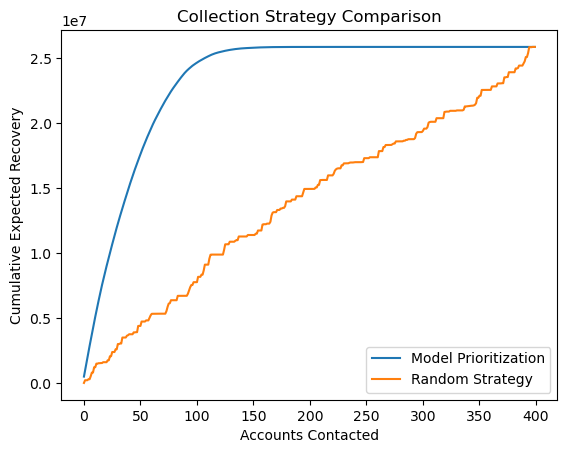

In [60]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    results_priority["cumlative_recovery"].values,
    label="Model Prioritization"
)

plt.plot(
    random_results["random_cumlative_recovery"].values,
    label="Random Strategy"
)

plt.xlabel("Accounts Contacted")
plt.ylabel("Cumulative Expected Recovery")
plt.title("Collection Strategy Comparison")

plt.legend()

plt.show()

Extract Logistic Coefficients

In [66]:
import pandas as pd

coefficients = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

print(coefficients)

dpd_bucket_hard                  3.859759e+00
previous_payments                1.774946e+00
employment_type_Self-employed    7.584186e-01
region_West                      6.283268e-01
income_segment_mid               5.119713e-01
high_risk_flag                   4.903938e-01
dpd_bucket_soft                  4.653777e-01
region_South                     1.889018e-01
employment_type_Salaried         1.551515e-01
payment_ratio                    4.076729e-05
outstanding_balance              9.802551e-08
income_segment_high              0.000000e+00
customer_income                 -7.370344e-06
region_North                    -1.908056e-02
attempt_intensity               -4.412428e-02
collection_attempts             -4.666306e-02
debt_to_income                  -1.036653e-01
dpd                             -1.446355e-01
income_segment_upper_mid        -2.685556e-01
dpd_bucket_late                 -3.369366e+00
dtype: float64


Positive drivers

In [67]:
coefficients.head(10)

dpd_bucket_hard                  3.859759
previous_payments                1.774946
employment_type_Self-employed    0.758419
region_West                      0.628327
income_segment_mid               0.511971
high_risk_flag                   0.490394
dpd_bucket_soft                  0.465378
region_South                     0.188902
employment_type_Salaried         0.155151
payment_ratio                    0.000041
dtype: float64

Negative drivers

In [68]:
coefficients.tail(10)

outstanding_balance         9.802551e-08
income_segment_high         0.000000e+00
customer_income            -7.370344e-06
region_North               -1.908056e-02
attempt_intensity          -4.412428e-02
collection_attempts        -4.666306e-02
debt_to_income             -1.036653e-01
dpd                        -1.446355e-01
income_segment_upper_mid   -2.685556e-01
dpd_bucket_late            -3.369366e+00
dtype: float64